# Employee Turnover Prediction
**Predicting and reducing employee attrition using machine learning and behavioral clustering**

## Project Overview

Employee attrition is one of the most costly challenges in workforce management. This project builds a machine learning pipeline to predict which employees are most likely to leave, using historical HR data from Portobello Tech.

The approach covers the full analysis lifecycle:

- **Exploratory Data Analysis** — identifying key drivers of attrition through correlation analysis and feature distributions
- **Behavioral Clustering** — segmenting employees who left into distinct groups using K-Means
- **Class Imbalance Handling** — applying SMOTE to prevent majority-class bias
- **Model Comparison** — evaluating Logistic Regression, Random Forest, and Gradient Boosting with 5-fold cross-validation
- **Risk Stratification** — categorizing employees into actionable risk zones with tailored retention strategies

**Best model: Gradient Boosting Classifier (AUC = 0.979)**

In [65]:
## Imports & Setup

# Data handling
import pandas as pd
import numpy as np
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler

# Clustering
from sklearn.cluster import KMeans

# Modeling
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation
from sklearn.metrics import (
    classification_report,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# SMOTE for class imbalance
from imblearn.over_sampling import SMOTE

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Plot styling
plt.style.use("seaborn-v0_8")





## Data Loading & Inspection

In [66]:
# Creating Folder Path And Loading Data
data_path = Path('../data/ibm_hr_attrition.csv')

raw_data = pd.read_csv(data_path, encoding='UTF-8')
df = raw_data.copy()



In [67]:
# Quick Inspection
display(df.head())
print('\nShape:', df.shape)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2



Shape: (1470, 35)


In [68]:
# Information About The Data
df.info()

# Summary Statistics
display(df.describe(include='all'))

for col in df.columns:
    unique_vals = df[col].unique()
    if len(unique_vals) < 20:  
        print(f"\nColumn: {col}")
        print(unique_vals)




<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470,1470,1470.000000,1470,1470.000000,1470.000000,1470,1470.0,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
unique,NaN,2,3,NaN,3,NaN,NaN,6,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,No,Travel_Rarely,NaN,Research & Development,NaN,NaN,Life Sciences,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1233,1043,NaN,961,NaN,NaN,606,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,36.923810,NaN,NaN,802.485714,NaN,9.192517,2.912925,NaN,1.0,1024.865306,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,NaN,NaN,403.509100,NaN,8.106864,1.024165,NaN,0.0,602.024335,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,NaN,NaN,102.000000,NaN,1.000000,1.000000,NaN,1.0,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,NaN,NaN,465.000000,NaN,2.000000,2.000000,NaN,1.0,491.250000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,NaN,NaN,802.000000,NaN,7.000000,3.000000,NaN,1.0,1020.500000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,NaN,NaN,1157.000000,NaN,14.000000,4.000000,NaN,1.0,1555.750000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000



Column: Attrition
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Column: BusinessTravel
<StringArray>
['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Length: 3, dtype: str

Column: Department
<StringArray>
['Sales', 'Research & Development', 'Human Resources']
Length: 3, dtype: str

Column: Education
[2 1 4 3 5]

Column: EducationField
<StringArray>
[   'Life Sciences',            'Other',          'Medical',
        'Marketing', 'Technical Degree',  'Human Resources']
Length: 6, dtype: str

Column: EmployeeCount
[1]

Column: EnvironmentSatisfaction
[2 3 4 1]

Column: Gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Column: JobInvolvement
[3 2 4 1]

Column: JobLevel
[2 1 3 4 5]

Column: JobRole
<StringArray>
[          'Sales Executive',        'Research Scientist',
     'Laboratory Technician',    'Manufacturing Director',
 'Healthcare Representative',                   'Manager',
      'Sales Representative',         'Research Director',
           'Human Reso

## Data Quality & Cleaning

In [69]:
# Checking For Missing Values And Duplicate Rows
print('\nNumber Of Missing Values:', df.isnull().sum().sum())
print('Number Of Duplicate Rows:', df.duplicated().sum())

print('Initial Shape:', df.shape)


COLS_TO_DROP = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df = df.drop(columns=COLS_TO_DROP)
print('Shape After Dropping Unnecessary Columns:', df.shape)



Number Of Missing Values: 0
Number Of Duplicate Rows: 0
Initial Shape: (1470, 35)
Shape After Dropping Unnecessary Columns: (1470, 31)


## Exploratory Data Analysis

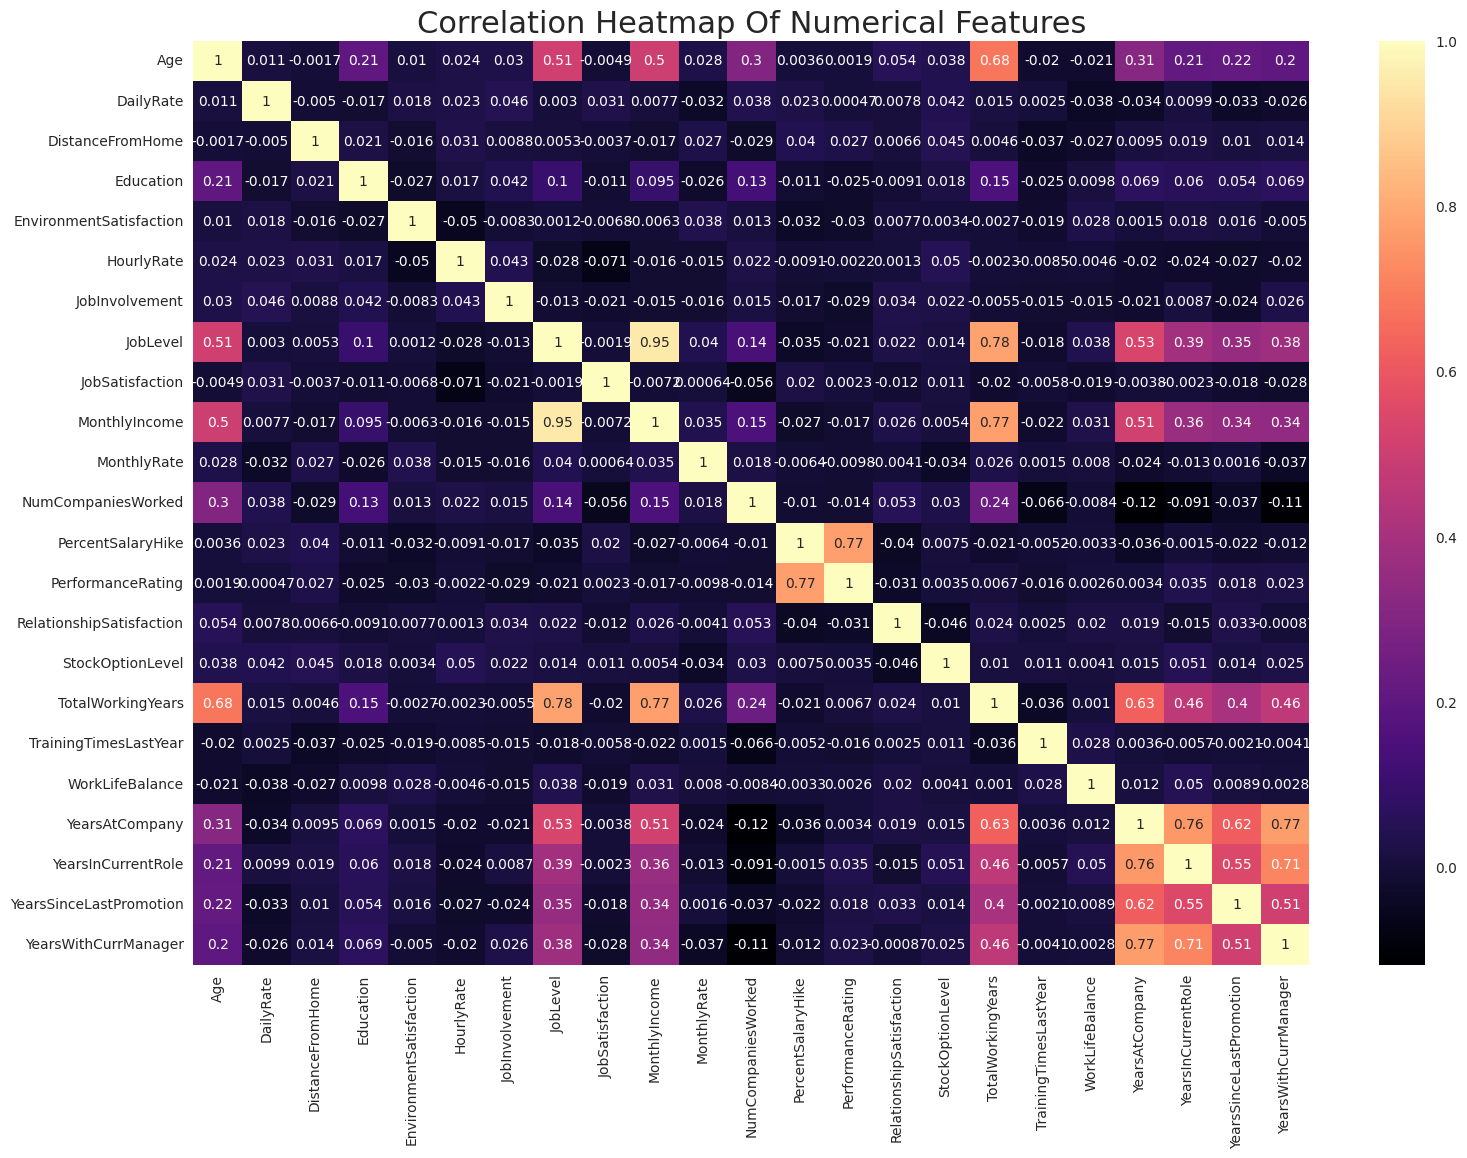

In [70]:
# Correlation Heatmap

numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(18, 12))
sns.heatmap(numeric_df.corr(), annot=True, cmap="magma")
plt.title("Correlation Heatmap Of Numerical Features", fontsize=22)
plt.savefig('../notebooks/figures/heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

### Correlation Analysis

The heatmap shows how strongly features are related to each other. The biggest standout is JobLevel and MonthlyIncome at 0.95. TotalWorkingYears, Age, and MonthlyIncome are all tied together too. Which makes sense, the longer you've worked, the older you are and the more you make.

The four "Years" columns: YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, and YearsWithCurrManager are all highly correlated with each other, so they're telling a similar story about how long someone has been around. 

On the flip side, DailyRate, HourlyRate, and MonthlyRate have almost no correlation with anything, so they probably won't help the model much.

In [ ]:
# Feature Distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Age'], kde=True, ax=axes[0], color='purple')
axes[0].set_title("Distribution of Age")

sns.histplot(df['MonthlyIncome'], kde=True, ax=axes[1], color='teal')
axes[1].set_title("Distribution of Monthly Income")

sns.histplot(df['TotalWorkingYears'], kde=True, ax=axes[2], color='orange')
axes[2].set_title("Distribution of Total Working Years")

plt.tight_layout()
plt.savefig('../notebooks/figures/hist_subplots.png', dpi=300, bbox_inches='tight')
plt.show()

### Feature Distributions

**Age** follows a roughly normal distribution centered around the mid-30s, with a slight right skew — most employees are in the 28–42 range, and attrition tends to be higher among younger employees early in their careers.

**Monthly Income** is heavily right-skewed, with most employees clustered at lower income bands and a long tail of high earners. This skew reflects the seniority pyramid and is consistent with the strong correlation between `JobLevel` and `MonthlyIncome` seen in the heatmap.

**Total Working Years** is similarly right-skewed — the majority of employees have fewer than 15 years of experience, while a smaller cohort has 20–40 years. Employees earlier in their careers show higher attrition rates, making this a meaningful predictor.

In [72]:
# Bar Plot - Project Count vs Attrition (who stayed vs who left)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='number_project', hue='left', palette='viridis')
plt.title('Number of Projects vs Employee Turnover', fontsize=14)
plt.xlabel('Number of Projects')
plt.ylabel('Count')
plt.savefig('../outputs/figures/bar_project_turnover.png', dpi=300, bbox_inches='tight')
plt.show()

ValueError: Could not interpret value `number_project` for `x`. An entry with this name does not appear in `data`.

<Figure size 800x500 with 0 Axes>

### Project Count vs. Attrition

Attrition follows a **U-shaped pattern** with respect to project count. Employees with very few projects (2) and very many projects (6-7) show disproportionately high turnover. This suggests both **understimulation** (too few projects) and **burnout** (too many) are independent drivers of attrition — a finding that directly informs workload management recommendations.

## Behavioral Clustering

Before building predictive models, K-Means clustering is applied to employees who left to identify distinct behavioral segments. This unsupervised step reveals *why* people leave, not just *that* they leave — enabling targeted retention strategies per segment.

In [ ]:
# Filtering Employees Who Left
left_df = df[df['Attrition'] == 1][['satisfaction_level', 'last_evaluation']]

# K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=123)
left_df['cluster'] = kmeans.fit_predict(left_df)

left_df.head(3)

,satisfaction_level,last_evaluation,cluster
0,0.38,0.53,2
1,0.80,0.86,1
2,0.11,0.88,0


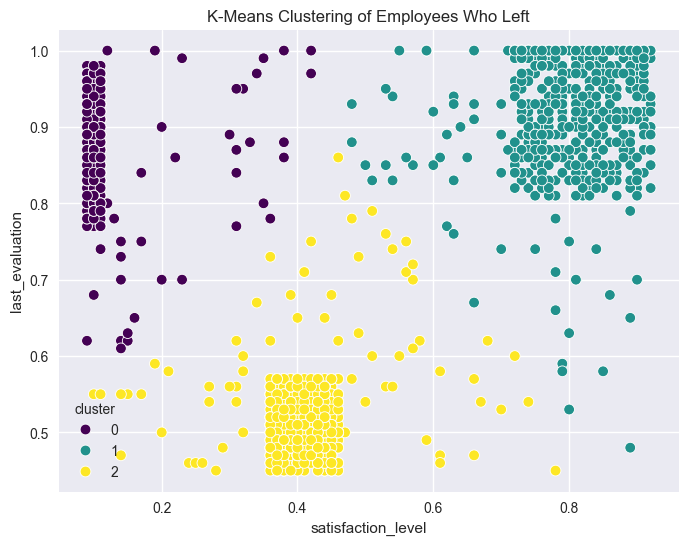

In [ ]:
# Visualizing The Clusters On A Plot

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=left_df,
    x='satisfaction_level',
    y='last_evaluation',
    hue='cluster',
    palette='viridis',
    s=60
)
plt.title("K-Means Clustering of Employees Who Left")
plt.savefig('../outputs/figures/k_means_cluster.png', dpi=300, bbox_inches='tight')
plt.show()

### Cluster Interpretation

Three distinct attrition profiles emerge:

1. **Burned Out High Performers** — High evaluation scores, low satisfaction. These employees delivered strong results but were likely overworked or under-recognized.
2. **Disengaged & Undervalued** — Low evaluation scores, low satisfaction. Classic disengagement pattern — may indicate poor management fit or role mismatch.
3. **Flight Risk Moderates** — Moderate on both axes. These employees aren't in crisis but aren't engaged enough to stay — often lost to better offers or lateral moves.

Each cluster warrants a different retention intervention, which is addressed in the final risk stratification.

## Data Preprocessing

Preparing features for modeling: encoding categorical variables, splitting into train/test sets with stratification to preserve class ratios, and scaling where needed.

In [ ]:
# Identifying And Preparing Numerical & Categorical Columns For Modeling
cat_columns = df.select_dtypes(include=['object']).columns.tolist()
num_columns = df.select_dtypes(include=['number']).columns.tolist()

print('Categorical Columns:', cat_columns)
print('Numerical Columns:', num_columns)

Categorical Columns: ['dept', 'salary']
Numerical Columns: ['satisfaction_level', 'last_evaluation', 'number_project', 'average_monthly_hours', 'time_spent_company', 'Work_accident', 'left', 'promotion_last_5years']


In [ ]:
#Encoding Categorical Columns
df_encoded = pd.get_dummies(df, columns=cat_columns, drop_first=True)

print('Shape Before Encoding:', df.shape)
print('Shape After Encoding:', df_encoded.shape)
df_encoded.head(3)

Shape Before Encoding: (11991, 10)
Shape After Encoding: (11991, 19)


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spent_company,Work_accident,left,promotion_last_5years,dept_RandD,dept_accounting,dept_hr,dept_management,dept_marketing,dept_product_mng,dept_sales,dept_support,dept_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False
1,0.80,0.86,5,262,6,0,1,0,False,False,False,False,False,False,True,False,False,False,True
2,0.11,0.88,7,272,4,0,1,0,False,False,False,False,False,False,True,False,False,False,True


In [ ]:
# Separating Features & Train-Test Split

X = df_encoded.drop('left', axis=1)
y = df_encoded['left']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123, stratify=y)

print("Training Set Shape:", X_train.shape)
print("Test Set Shape:", X_test.shape)
print("Class Balance in Train:", y_train.value_counts(normalize=True))
print("Class Balance in Test:", y_test.value_counts(normalize=True))

Training Set Shape: (9592, 18)
Test Set Shape: (2399, 18)
Class Balance in Train: left
0    0.833924
1    0.166076
Name: proportion, dtype: float64
Class Balance in Test: left
0    0.834098
1    0.165902
Name: proportion, dtype: float64


## Handling Class Imbalance with SMOTE

The original dataset has approximately 76% stayed vs. 24% left. Without correction, models could achieve 76% accuracy by simply predicting "stayed" for every employee — technically high accuracy, but operationally useless.

**SMOTE (Synthetic Minority Oversampling Technique)** generates synthetic examples of the minority class by interpolating between existing data points. This is applied only to the training set — the test set remains untouched to ensure evaluation reflects real-world class distribution.

In [ ]:
# Applying SMOTE To The Training Set

sm = SMOTE(random_state=123)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("\nAfter SMOTE:", y_train_sm.value_counts())

Before SMOTE: left
0    7999
1    1593
Name: count, dtype: int64

After SMOTE: left
0    7999
1    7999
Name: count, dtype: int64


## Model Training

Three classifiers are compared, each representing a different modeling strategy:

- **Logistic Regression** — Linear baseline. Fast, interpretable, and establishes a performance floor.
- **Random Forest** — Bagging ensemble. Reduces variance by averaging many independent decision trees.
- **Gradient Boosting** — Boosting ensemble. Reduces bias by building trees sequentially, with each tree correcting errors from the previous one.

All models are evaluated with **5-fold stratified cross-validation** to ensure performance estimates are robust and not artifacts of a single lucky split.

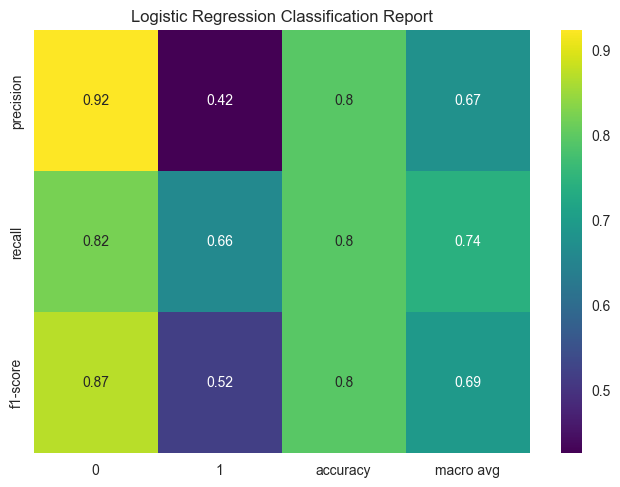

In [ ]:
# Model Training - Logistic Regression With 5-Fold Cross-Validation
log_reg = LogisticRegression(max_iter=1000)

# Cross-Validation Setup
log_cv_scores = cross_val_score(
    log_reg,
    X_train_sm,
    y_train_sm,
    cv=5,
    scoring='accuracy'
)


# Fitting the SMOTE Training Set on Model
log_reg.fit(X_train_sm, y_train_sm)

# Classification Report Plot
log_pred = log_reg.predict(X_test)

log_report =classification_report(y_test, log_pred, output_dict=True)

sns.heatmap(pd.DataFrame(log_report).iloc[:-1, :-1].astype(float),
            annot=True, cmap='viridis')

plt.title('Logistic Regression Classification Report')
plt.savefig('../outputs/figures/log_classification.png', dpi=300, bbox_inches='tight')
plt.show()


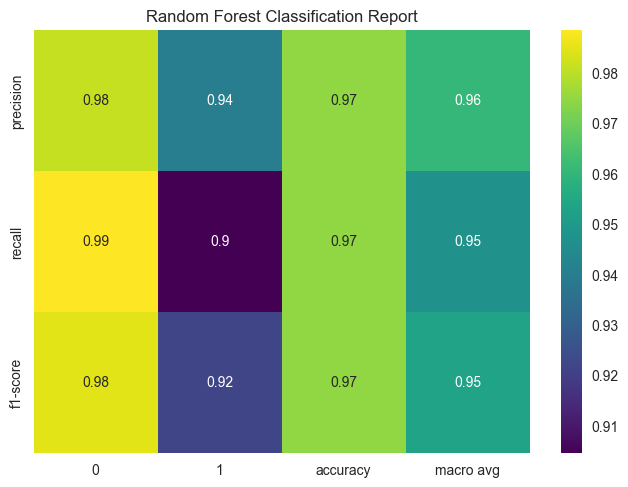

In [ ]:
# Model Training - Random Forest With 5-Fold Cross-Validation
forest = RandomForestClassifier(random_state=123)

# Cross-Validation Setup
log_cv_scores = cross_val_score(
    forest,
    X_train_sm,
    y_train_sm,
    cv=5,
    scoring='accuracy'
)


# Fitting the SMOTE Training Set on Model
forest.fit(X_train_sm, y_train_sm)

# Classification Report
forest_pred = forest.predict(X_test)

forest_report =classification_report(y_test, forest_pred, output_dict=True)

sns.heatmap(pd.DataFrame(forest_report).iloc[:-1, :-1].astype(float),
            annot=True, cmap='viridis')

plt.title('Random Forest Classification Report')
plt.savefig('../outputs/figures/forest_classification.png', dpi=300, bbox_inches='tight')
plt.show()



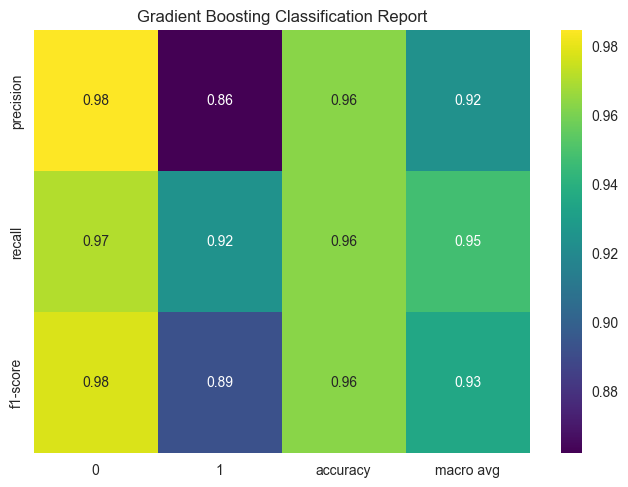

In [ ]:
# Model Training - Gradient Boosting Classifier With 5-Fold Cross-Validation
gb = GradientBoostingClassifier(random_state=123)

# Cross-Validation Setup
log_cv_scores = cross_val_score(
    gb,
    X_train_sm,
    y_train_sm,
    cv=5,
    scoring='accuracy'
)


# Fitting the SMOTE Training Set on Model
gb.fit(X_train_sm, y_train_sm)

# Classification Report
gb_pred = gb.predict(X_test)

gb_report =classification_report(y_test, gb_pred, output_dict=True)

sns.heatmap(pd.DataFrame(gb_report).iloc[:-1, :-1].astype(float),
            annot=True, cmap='viridis')

plt.title('Gradient Boosting Classification Report')
plt.savefig('../outputs/figures/gb_classification.png', dpi=300, bbox_inches='tight')
plt.show()



## Model Evaluation & Comparison

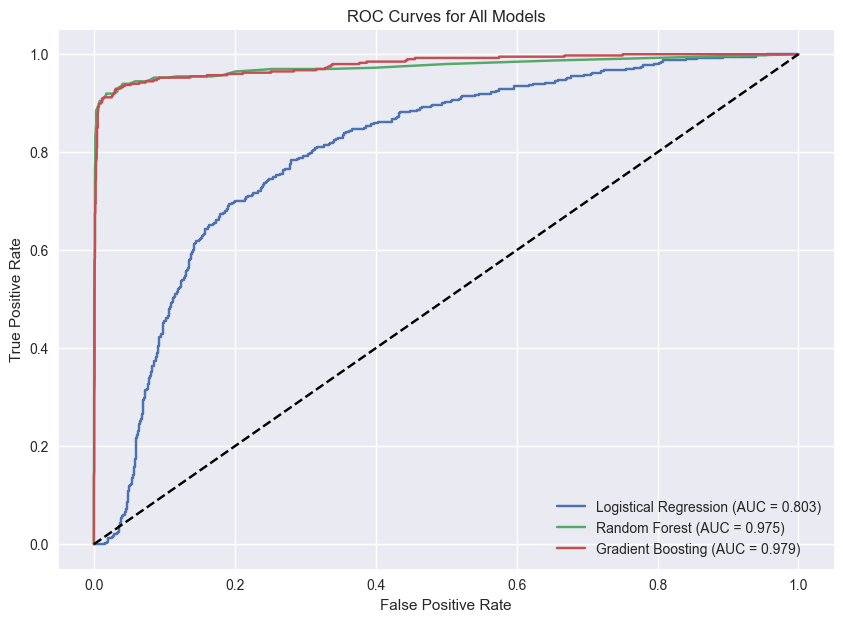

In [ ]:
# Calculating ROC Curve & AUC For All Models

models = {
    'Logistical Regression': (log_reg, log_pred),
    'Random Forest': (forest, forest_pred),
    'Gradient Boosting': (gb, gb_pred)
}

plt.figure(figsize=(10, 7))

for name, (model, preds) in models.items():
    prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _= roc_curve(y_test, prob)
    auc_score = roc_auc_score(y_test, prob)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend()
plt.savefig('../outputs/figures/roc_auc.png', dpi=300, bbox_inches='tight')
plt.show()

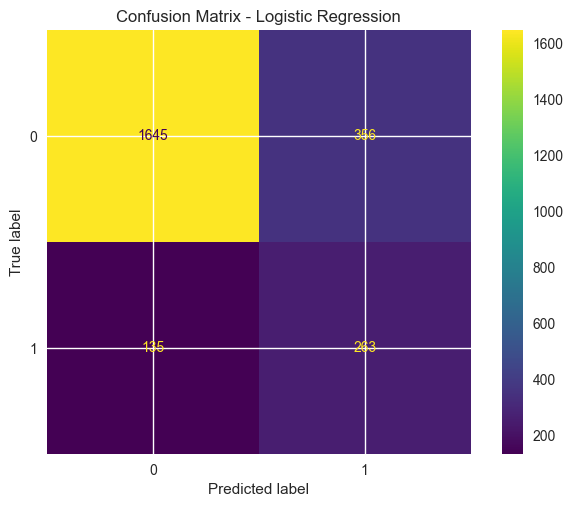

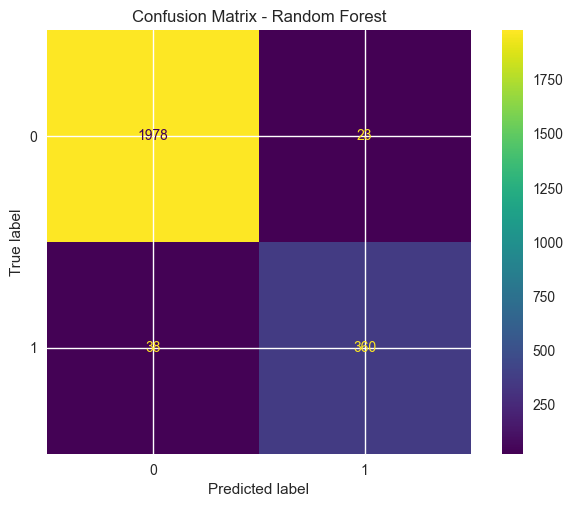

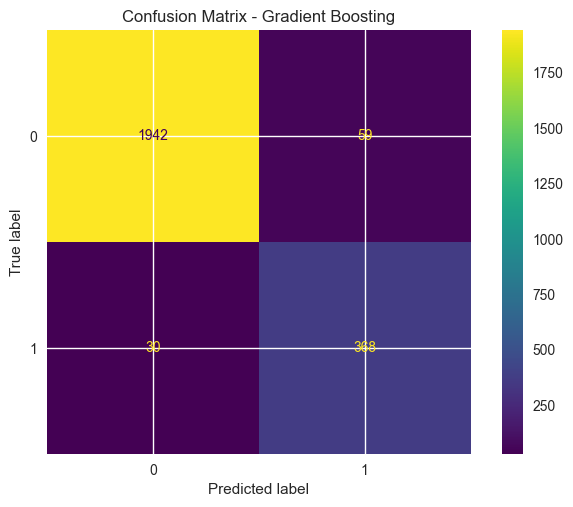

In [ ]:
# Confusion Matrices For All Models
model_predictions = {
    'Logistic Regression': log_pred,
    'Random Forest': forest_pred,
    'Gradient Boosting': gb_pred
}

for name, preds in model_predictions.items():
    cm_display = ConfusionMatrixDisplay.from_predictions(y_test, preds, cmap='viridis')
    plt.title(f'Confusion Matrix - {name}')
    plt.savefig('../outputs/figures/confusion_matrices.png', dpi=300, bbox_inches='tight')
    plt.show()

### Confusion Matrix Analysis

All three models demonstrate strong True Positive capture, but Gradient Boosting achieves the highest count. Both Random Forest and Gradient Boosting show strong **recall** — the critical metric for this use case.

**Why recall matters here:** A false negative (missing an at-risk employee) is far more costly than a false positive (flagging someone who would have stayed). HR can always conduct a check-in with a flagged employee — but they can't retain someone who's already gone. High recall ensures the model catches as many at-risk employees as possible.

### ROC/AUC Comparison

| Model | AUC Score |
|---|---|
| Logistic Regression | 0.803 |
| Random Forest | 0.975 |
| Gradient Boosting | **0.979** |

The **Gradient Boosting Classifier** achieves the highest AUC, indicating superior discriminative ability across all probability thresholds. It correctly ranks nearly every employee by their likelihood of leaving.

**Selected model: Gradient Boosting** — based on highest AUC and strongest recall for the minority class.

## Turnover Probability Prediction

Using the selected Gradient Boosting model to generate turnover probabilities for every employee in the test set. These probabilities power the risk stratification system below.

In [ ]:
# Predicting Probabilities Of Employee Turnover With Best Model
best_model = gb
y_prob = best_model.predict_proba(X_test)[:, 1]

results_df = X_test.copy()
results_df['actual_left'] = y_test
results_df['probability_left'] = y_prob

results_df[['probability_left', 'actual_left']].head(10)


,probability_left,actual_left
8578,0.216481,0
5756,0.763488,0
3994,0.034544,0
1784,0.862630,1
10508,0.070988,0
1539,0.930714,1
8563,0.457466,0
6163,0.103448,0
4239,0.005408,0
7919,0.039665,0


## Risk Stratification & Retention Strategy

Translating model predictions into actionable HR categories. Each employee is assigned to a risk zone based on their predicted probability of leaving, with tailored intervention strategies per zone.

In [ ]:
# Categorizing Employees Into Risk Zones

def categorize_risk(prob):
    if prob < 0.20:
        return 'Safe Zone (Green)'
    elif prob < 0.60:
        return 'Low Risk (Yellow)'
    elif prob < 0.90:
        return 'Medium Risk (Orange)'
    else:
        return 'High Risk (Red)'
    
results_df['risk_zone'] = results_df['probability_left'].apply(categorize_risk)


results_df['risk_zone'].value_counts()


risk_zone
Safe Zone (Green)       1845
High Risk (Red)          335
Low Risk (Yellow)        150
Medium Risk (Orange)      69
Name: count, dtype: int64

### Retention Strategies by Risk Zone

**Safe Zone (< 20% probability)**
Employees showing strong satisfaction, good performance alignment, and low stress indicators.
- Maintain current working conditions and recognition cadence
- Provide skill development opportunities to sustain engagement
- Monitor periodically to prevent drift into higher-risk categories

---

**Low Risk (20–60% probability)**
Mostly stable employees with emerging risk factors — fluctuating satisfaction or inconsistent evaluations.
- Conduct regular 1:1 check-ins with direct managers
- Offer optional training, mentorship, or growth paths
- Audit workload balance and assignment equity

---

**Medium Risk (60–90% probability)**
Noticeable disengagement signals — potential burnout, workload misalignment, or evaluation gaps.
- Initiate targeted retention conversations
- Redistribute projects or adjust scope
- Provide clear feedback and professional development plans
- Recognize recent contributions explicitly

---

**High Risk (> 90% probability)**
Employees with the highest predicted probability of departure — often driven by sustained low satisfaction, extreme workload, or management friction.
- Immediate 1:1 engagement with HR and direct manager
- Address root causes: workload stress, interpersonal issues, role misalignment
- Offer concrete retention incentives: promotion paths, role adjustments, compensation review
- Implement weekly monitoring until risk score decreases